# Task 0 · Gradient boosting baseline

The team's reference model, built on the shared benchmark in [`forecast/`](forecast/). See [`TASK0_README.md`](TASK0_README.md) for the rules and the evaluation.

- **Day-ahead rule:** the forecast for day D is made at the end of day D-1. It uses load and weather up to D-1, nothing from day D.
- **Data processing choice:** `Config(weather_resampling=...)` sets how hourly weather becomes 15-min values, `"step"` or `"interpolate"`.
- **Output:** `evaluate.evaluate` prints the scores (nMAE, R²) of this run. Nothing is written to the leaderboard; to add a run there, call `evaluate.submit(...)` (see section 3).

Runtime ≈ 3 min (the first run also builds `cache/`), peak memory ≈ 6 GB.

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

from forecast import Config, baselines, data, evaluate, features

config = Config(weather_resampling="step")  # "step" or "interpolate"
NAME = f"gbm_{config.weather_resampling}"  # label of this run (and its name if you submit it)
AUTHOR = "pengxuanHuang"
MODEL_PARAMS = dict(max_iter=300, learning_rate=0.1, categorical_features="from_dtype", random_state=0)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Standard features

In [ ]:
df = features.build_features(config)
FEATURES = features.standard_features()
train, test = features.split(df, config)
print(f"{len(FEATURES)} features · train sample {len(train):,} rows · test {len(test):,} rows")
FEATURES

26 features · train sample 3,000,000 rows · test 12,471,135 rows


['temperature_1d',
 'temperature_day_mean_1d',
 'sunshine_1d',
 'humidity_1d',
 'wind_speed_1d',
 'sunshine_filled_1d',
 'quarter_hour',
 'weekday',
 'month',
 'kwh_lag_1d',
 'kwh_lag_7d',
 'is_treatment',
 'after_visit',
 'has_pv',
 'Survey_Building_LivingArea',
 'Survey_Building_Residents',
 'Survey_Building_Type',
 'Survey_HeatPump_Installation_Type',
 'Survey_HeatDistribution_System_FloorHeating',
 'Survey_HeatDistribution_System_Radiator',
 'Survey_DHW_Production_ByHeatPump',
 'Survey_DHW_Production_ByElectricWaterHeater',
 'Survey_DHW_Production_BySolar',
 'Survey_Installation_HasDryer',
 'Survey_Installation_HasFreezer',
 'Survey_Installation_HasElectricVehicle']

## 2. Train

In [ ]:
model = HistGradientBoostingRegressor(**MODEL_PARAMS)
model.fit(train[FEATURES], train["kwh"])

HistGradientBoostingRegressor(max_iter=300, random_state=0)

## 3. Predict and evaluate

`evaluate.evaluate` scores every test row with the standard evaluation and only prints the result. To put a run on the shared leaderboard, uncomment the `evaluate.submit` line.

In [ ]:
predictions = test[["Household_ID", "Timestamp"]].assign(prediction=model.predict(test[FEATURES]).clip(min=0))
print(f"{NAME}: nMAE % and R² per level")
display(evaluate.evaluate(predictions).round(3))

# evaluate.submit(predictions, NAME, AUTHOR,
#                 description=f"HistGradientBoosting, standard features, weather {config.weather_resampling}",
#                 config=config.to_dict(), params=MODEL_PARAMS)

gbm_step: nMAE % and R² per level


,MAE,RMSE,nMAE,bias
portfolio_15min,11.654,16.466,11.611,0.929
portfolio_day,752.471,1113.287,7.817,0.927
household_15min,0.175,0.287,62.541,0.929
household_day,5.792,8.902,21.510,0.927


# 3.1 Validation to optimize the hyperparameters of HGB

## 4. Reference baselines

Naive forecasts every model should beat, scored the same way (printed only).

In [ ]:
# All forecasts of this run, used by the comparisons below
runs = {
    NAME: predictions,
    "naive_lag_1d": baselines.naive(df, "kwh_lag_1d"),  # same 15 min yesterday
    "naive_lag_7d": baselines.naive(df, "kwh_lag_7d"),  # same 15 min one week ago
}
scores = {name: evaluate.evaluate(p) for name, p in runs.items()}
for name in ("naive_lag_1d", "naive_lag_7d"):
    print(f"{name}: nMAE % and R² per level")
    display(scores[name].round(3))

## 5. Comparison of this run

Side by side, and the daily portfolio energy over the test winter. `evaluate.leaderboard()` still shows the shared leaderboard (submitted runs only).

In [ ]:
pd.concat({name: s.stack() for name, s in scores.items()}, axis=1).T.round(3)

portfolio_15min                        portfolio_day            \
                         MAE    RMSE    nMAE   bias           MAE      RMSE   
gbm_step              11.654  16.466  11.611  0.929       752.471  1113.287   
naive_lag_1d          13.462  19.246  13.413  0.276       760.878  1148.258   
naive_lag_7d          20.529  30.043  20.454  0.602      1628.862  2459.917   

                            household_15min                        \
                nMAE   bias             MAE   RMSE    nMAE   bias   
gbm_step       7.817  0.927           0.175  0.287  62.541  0.929   
naive_lag_1d   7.904  0.198           0.194  0.371  69.229  0.276   
naive_lag_7d  16.921  0.521           0.205  0.380  73.035  0.602   

             household_day                         
                       MAE    RMSE    nMAE   bias  
gbm_step             5.792   8.902  21.510  0.927  
naive_lag_1d         5.476   9.234  20.337  0.198  
naive_lag_7d         7.871  12.724  29.228  0.521

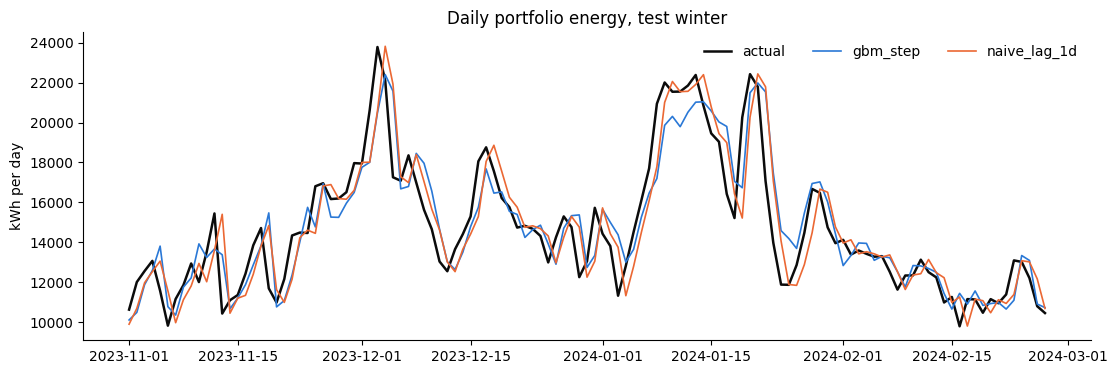

In [ ]:
truth = data.ground_truth()
COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]

# Daily portfolio energy: actual vs the forecasts of this run (partial last test day left out)
day = truth["Timestamp"].dt.tz_convert("Europe/Berlin").dt.date
daily = pd.DataFrame({"actual": truth["kwh"].groupby(day).sum()})
for name, p in runs.items():
    aligned = truth[["Household_ID", "Timestamp"]].merge(p, on=["Household_ID", "Timestamp"], how="left")
    daily[name] = aligned["prediction"].groupby(day.to_numpy()).sum()
daily = daily[daily["actual"] > 0.5 * daily["actual"].median()]
daily.index = pd.to_datetime(daily.index)
winter = daily.loc["2023-11-01":]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(winter.index, winter["actual"], color="#0b0b0b", linewidth=1.8, label="actual")
for name, color in zip(runs, COLORS[:2]):
    ax.plot(winter.index, winter[name], color=color, linewidth=1.2, label=name)
ax.set(title="Daily portfolio energy, test winter", ylabel="kWh per day")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=3)
plt.show()

## 6. R² score

R² = 1 − Σ(actual − predicted)² / Σ(actual − mean actual)²: the share of the variation in consumption that the forecast explains. 1 is perfect, 0 is no better than always predicting the average, and below 0 is worse than that.

The bar chart compares R² of this model and the naive baselines at all four evaluation levels. The scatter plots show predicted vs actual portfolio consumption for this model: the closer the points lie to the dashed 1:1 line, the higher R².

In [ ]:
r2 = pd.DataFrame({name: s["R2"] for name, s in scores.items()})

# Portfolio sums of this model, for predicted-vs-actual
m = truth.merge(predictions, on=["Household_ID", "Timestamp"], how="left")
portfolio_15min = m.groupby("Timestamp")[["kwh", "prediction"]].sum()
portfolio_day = m.groupby(day.to_numpy())[["kwh", "prediction"]].sum()
portfolio_day = portfolio_day[portfolio_day["kwh"] > 0.5 * portfolio_day["kwh"].median()]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), width_ratios=[1.4, 1, 1])

# 1) R² per level and forecast
x = np.arange(len(r2.index))
width = 0.8 / len(r2.columns)
for i, (name, color) in enumerate(zip(r2.columns, COLORS)):
    bars = axes[0].bar(x + (i - (len(r2.columns) - 1) / 2) * width, r2[name], width * 0.92, color=color, label=name)
    axes[0].bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
axes[0].set(xticks=x, xticklabels=[lvl.replace("_", "\n") for lvl in r2.index], ylabel="R²",
            title="R² by level (1 = perfect, 0 = as good as the mean)")
axes[0].axhline(0, color="#8a8984", linewidth=0.8)
axes[0].set_ylim(top=max(1.0, r2.max().max()) * 1.18)  # room for the legend above the bars
axes[0].legend(frameon=False, fontsize=8, ncol=len(r2.columns), loc="upper center")

# 2) and 3) predicted vs actual, with the 1:1 line
panels = [("Portfolio · 15 min", "portfolio_15min", portfolio_15min),
          ("Portfolio · day", "portfolio_day", portfolio_day)]
for ax, (title, level, t) in zip(axes[1:], panels):
    many = len(t) > 1000
    ax.scatter(t["kwh"], t["prediction"], s=4 if many else 14, alpha=0.25 if many else 0.6,
               color=COLORS[0], linewidths=0)
    hi = max(t["kwh"].max(), t["prediction"].max()) * 1.03
    ax.plot([0, hi], [0, hi], color="#52514e", linewidth=1, linestyle="--")
    ax.set(xlim=(0, hi), ylim=(0, hi), aspect="equal", xlabel="actual (kWh)", ylabel="predicted (kWh)",
           title=f"{title}: R² = {r2.loc[level, NAME]:.3f}")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

KeyError: 'R2'